#Part 1

####Import libraries and helping functions.

In [ ]:
import numpy as np

def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
  return x*(1-x)

#####XOR Dataset

In [ ]:
X=np.array([
    [0,0] ,[0,1],[1,0],[1,1]
])
y=np.array([[0],[1],[1],[0]]) #outputs

######Random weight intiliazation

In [ ]:
np.random.seed(42)
input_size=2
hidden_size=2
output_size=1

W1=np.random.uniform(size=(input_size,hidden_size))
W2=np.random.uniform(size=(hidden_size,output_size))
b1=np.random.uniform(size=(1,hidden_size))
b2=np.random.uniform(size=(1,output_size))


Training Parameters

In [ ]:
epochs=10000
lr=0.1



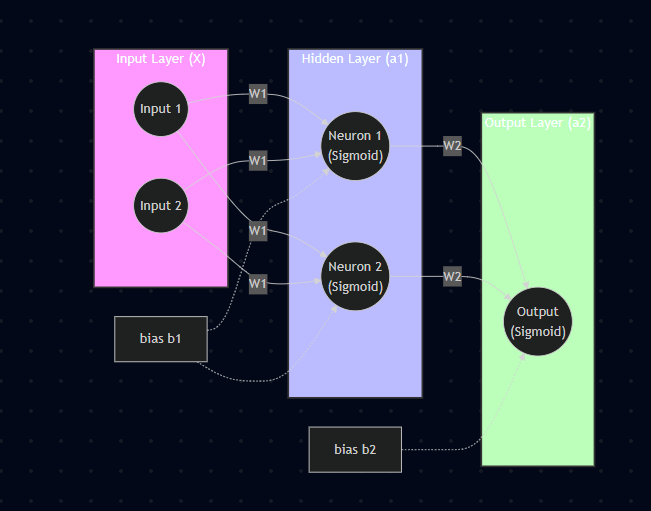

Training loop

In [ ]:
for epoch in range(epochs):
  z1=np.dot(X,W1)+b1
  a1=sigmoid(z1)

  z2=np.dot(a1,W2)+b2
  a2=sigmoid(z2) #final output

  #Error
  error=y-a2

  #Back Propagation
  d2=error*sigmoid_derivative(a2)
  d1=d2.dot(W2.T)*sigmoid_derivative(a1)

  #update weights and bias
  W2+=a1.T.dot(d2)*lr
  b2+=np.sum(d2,axis=0,keepdims=True)*lr
  W1+=X.T.dot(d1)*lr
  b1+=np.sum(d1,axis=0,keepdims=True)*lr

  #Print loss
  if epoch%1000==0:
    loss=np.mean(np.square(error))
    print(f"Epoch: {epoch}, Loss: {loss:.4f}")


Epoch: 0, Loss: 0.2880
Epoch: 1000, Loss: 0.2494
Epoch: 2000, Loss: 0.2457
Epoch: 3000, Loss: 0.2200
Epoch: 4000, Loss: 0.1622
Epoch: 5000, Loss: 0.0527
Epoch: 6000, Loss: 0.0169
Epoch: 7000, Loss: 0.0089
Epoch: 8000, Loss: 0.0058
Epoch: 9000, Loss: 0.0043


Final Predictions

In [ ]:
print("Final Predictions")
for i in range(len(X)):
  print(f"Input: {X[i]} ---> Predicted: {a2[i][0]:.4f}, Expected:{y[i][0]}")

Final Predictions
Input: [0 0] ---> Predicted: 0.0603, Expected:0
Input: [0 1] ---> Predicted: 0.9445, Expected:1
Input: [1 0] ---> Predicted: 0.9444, Expected:1
Input: [1 1] ---> Predicted: 0.0600, Expected:0


#Part 2

Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons,make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

Generate and visualize synthetic dataset

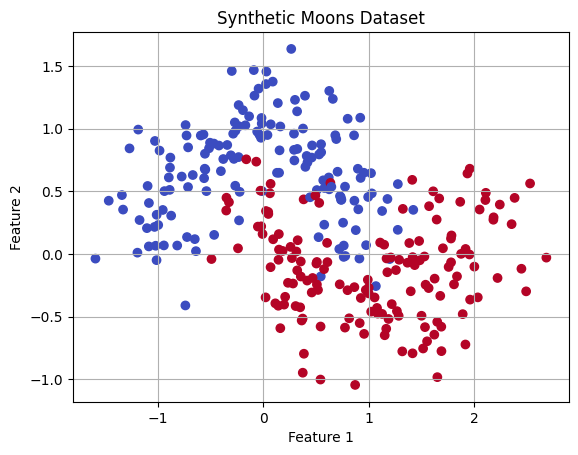

In [ ]:

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title("Synthetic Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='coolwarm')
    plt.title("Decision Boundary of MLP Classifier")
    plt.show()

In [ ]:
np.random.seed(42)
input_size=X.shape[1]
hidden_size=10
output_size=1

W1=np.random.uniform(size=(input_size,hidden_size))
W2=np.random.uniform(size=(hidden_size,output_size))
b1=np.random.uniform(size=(1,hidden_size))
b2=np.random.uniform(size=(1,output_size))


In [ ]:
y=y.reshape(-1,1)

epochs=15000
lr=0.1
for epoch in range(epochs):
  z1=np.dot(X,W1)+b1
  a1=sigmoid(z1)

  z2=np.dot(a1,W2)+b2
  a2=sigmoid(z2) #final output

  #Error
  error=y-a2

  #Back Propagation
  d2=error*sigmoid_derivative(a2)
  d1=d2.dot(W2.T)*sigmoid_derivative(a1)

  #update weights and bias
  W2+=a1.T.dot(d2)*lr
  b2+=np.sum(d2,axis=0,keepdims=True)*lr
  W1+=X.T.dot(d1)*lr
  b1+=np.sum(d1,axis=0,keepdims=True)*lr

  #Print loss
  if epoch%1000==0:
    loss=np.mean(np.square(error))
    print(f"Epoch: {epoch}, Loss: {loss:.4f}")


Epoch: 0, Loss: 0.4458
Epoch: 1000, Loss: 0.0474
Epoch: 2000, Loss: 0.0467
Epoch: 3000, Loss: 0.0463
Epoch: 4000, Loss: 0.0461
Epoch: 5000, Loss: 0.0458
Epoch: 6000, Loss: 0.0456
Epoch: 7000, Loss: 0.0454
Epoch: 8000, Loss: 0.0452
Epoch: 9000, Loss: 0.0450
Epoch: 10000, Loss: 0.0449
Epoch: 11000, Loss: 0.0447
Epoch: 12000, Loss: 0.0445
Epoch: 13000, Loss: 0.0441
Epoch: 14000, Loss: 0.0425


In [ ]:
class MLP_Classifier:
  def __init__(self,W1,b1,W2,b2):
    self.W1=W1
    self.W2=W2
    self.b1=b1
    self.b2=b2

  def predict(self,X_test):
    z1=np.dot(X_test,self.W1)+self.b1
    a1=sigmoid(z1)

    z2=np.dot(a1,self.W2)+self.b2
    a2=sigmoid(z2) #final output
    return (a2>0.5).astype(int)

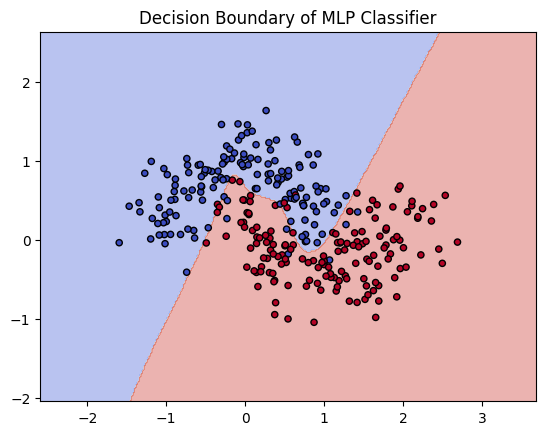

In [ ]:
mlp_model=MLP_Classifier(W1,b1,W2,b2)
plot_decision_boundary(mlp_model,X,y.flatten().astype(int))